In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [32]:
df = pd.read_csv('spam.csv')

print(df.head())

print(f"\nDataset Shape (Rows, Columns): {df.shape}")
print(df['Category'].value_counts())


  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...

Dataset Shape (Rows, Columns): (5572, 2)
Category
ham     4825
spam     747
Name: count, dtype: int64


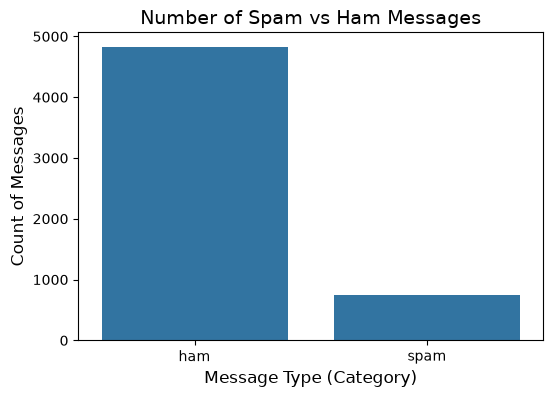

In [34]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Category', data=df)

plt.title('Number of Spam vs Ham Messages', fontsize=14)
plt.xlabel('Message Type (Category)', fontsize=12)
plt.ylabel('Count of Messages', fontsize=12)

plt.show()

In [35]:
# Convert text labels into numerical values
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})

X = df['Message']
y = df['Category']

print("Data preparation complete! 'ham' is now 0 and 'spam' is now 1.")

Data preparation complete! 'ham' is now 0 and 'spam' is now 1.


In [36]:
# Divide the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} messages")
print(f"Testing data size: {X_test.shape[0]} messages")

Training data size: 4457 messages
Testing data size: 1115 messages


In [41]:
vectorizer = CountVectorizer(stop_words='english')

X_train_vector = vectorizer.fit_transform(X_train)
X_test_vector = vectorizer.transform(X_test)

print("Text messages successfully converted into numerical matrices!")

Text messages successfully converted into numerical matrices!


In [42]:
model = LogisticRegression()
model.fit(X_train_vector, y_train)

print("Model training complete! The model has learned to distinguish between Ham (0) and Spam (1).")

Model training complete! The model has learned to distinguish between Ham (0) and Spam (1).


In [45]:
# Predict labels for the test messages
predictions = model.predict(X_test_vector)

print("Predictions successfully stored in the 'predictions' variable!")


Predictions successfully stored in the 'predictions' variable!


Model Accuracy: 98.39%



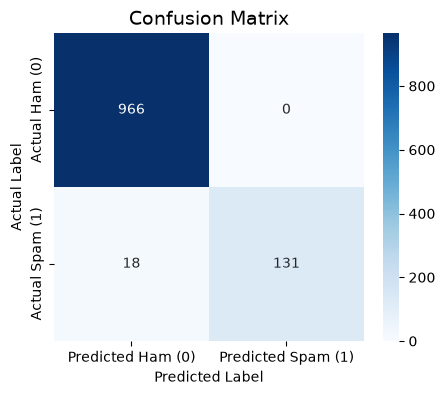

The model correctly classified a total of 1097 messages.


In [52]:
# Calculate accuracy score
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham (0)', 'Predicted Spam (1)'],
            yticklabels=['Actual Ham (0)', 'Actual Spam (1)'])

plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Calculate total correct predictions dynamically
correct_predictions = cm[0, 0] + cm[1, 1]
print(f"The model correctly classified a total of {correct_predictions} messages.")

In [ ]:
# Take a new SMS message from the user
user_sms = input("Enter a message to check for spam: ")

user_transformed = vectorizer.transform([user_sms])

user_prediction = model.predict(user_transformed)

print(f"\nYour Message: \"{user_sms}\"")
if user_prediction[0] == 0:
    print("📩 HAM MESSAGE")
else:
    print("🚨 SPAM MESSAGE")


Your Message: "Lottery!! Just buy a $50 ticket to claim $20,000 !!!!! REGISTER NOW!!"
🚨 SPAM MESSAGE
